<a href="https://colab.research.google.com/github/yunju-1118/ESAA/blob/OB/ESAA_OB_week11_1_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **딥러닝**

## **1. 인공 신경망의 한계와 딥러닝 출현**

오늘날 인공신경망에서 이용하는 구조는 Frank Rosenblatt가 1957년 고안한 퍼셉트론이라는 선형 분류기이다. 이 퍼셉트론은 오늘날 딥러닝의 기원이 되는 알고리즘이다.

퍼셉트론은 다수의 신호를 입력으로 받아 하나의 신호를 출력하는데, 이 신호를 입력으로 받아 정보를 앞으로 전달하는 원리로 작동한다.

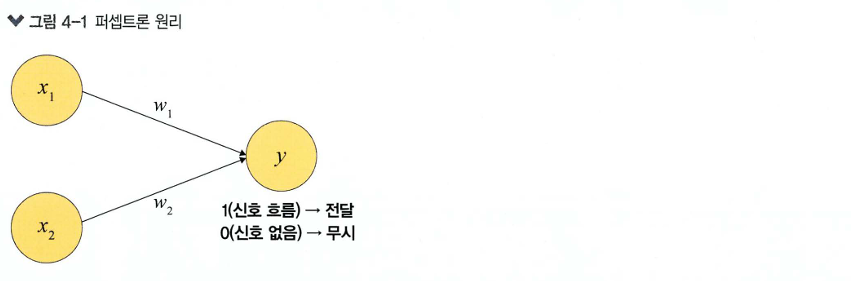

**AND 게이트**

AND 게이트는 모든 입력이 '1'일 때 작동한다. 즉, 입력 중 어떤 하나라도 '0'을 갖는다면 작동을 멈춘다.

AND 게이트에서는 다음 그림과 같은 데이터 분류로 표현할 수 있다.

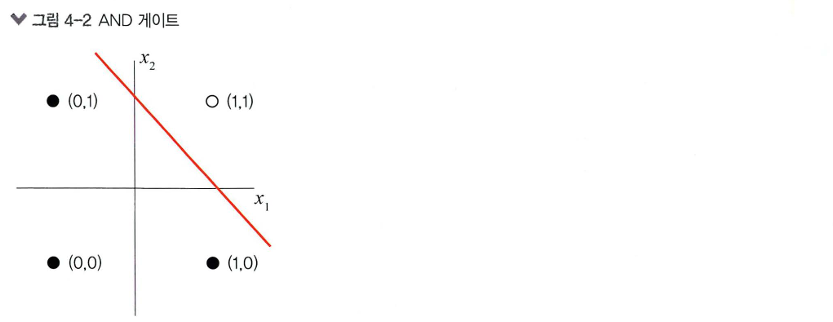

**OR 게이트**

OR 게이트는 입력에서 둘 중 하나만 '1'이거나 둘 다 '1'일 때 작동한다. 즉, 입력 모두가 '0'을 갖는 경우를 제외한 나머지가 모두 '1' 값을 갖는다.

OR 게이트에서도 다음 그림과 같은 데이터 분류로 표현할 수 있다.

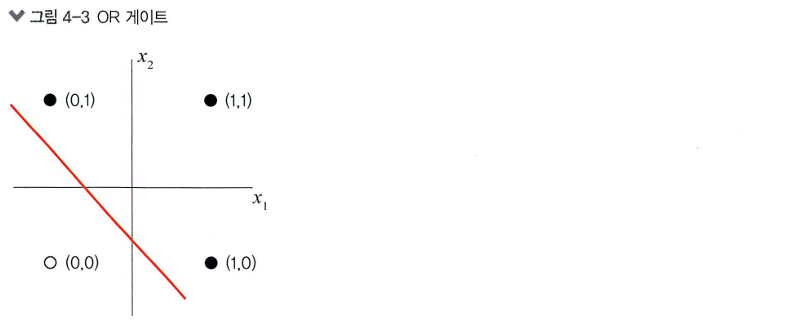

**XOR 게이트**

XOR 게이트는 배타적 논리합이라는 용어로 입력 두 개 중 한 개만 '1'일 때 작동하는 논리 연산이다.

XOR 게이트는 데이터가 비선형적으로 분리되기 때문에 제대로 된 분류가 어렵다. 즉, 단층 퍼셉트론에서는 AND, OR 연산에 대해서는 학습이 가능하지만, XOR에 대해서는 학습이 불가능하다.

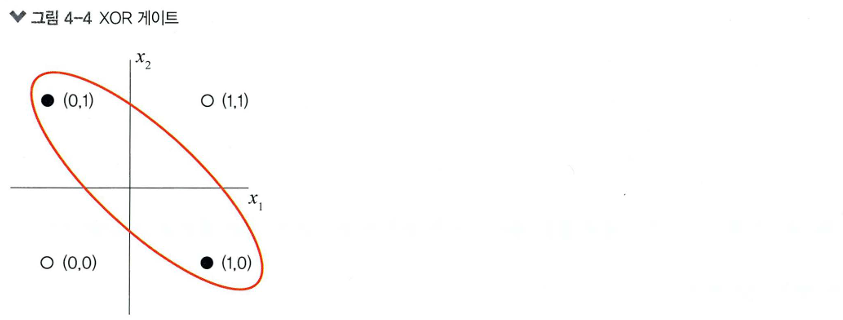

이를 극복하는 방안으로 입력층과 출력층 사이에 하나 이상의 중간층을 두어 비선형적으로 분리되는 데이터에 대해서도 학습이 가능하도록 **다층 퍼셉트론**을 고안했다.

이때, 입력층과 출력층 사이에 은닉층이 여러 개 있는 신경망을 심층 신경망이라고 하며, 이를 딥러닝이라고도 한다.

## **2. 딥러닝 구조**

### **2.1. 딥러닝 용어**

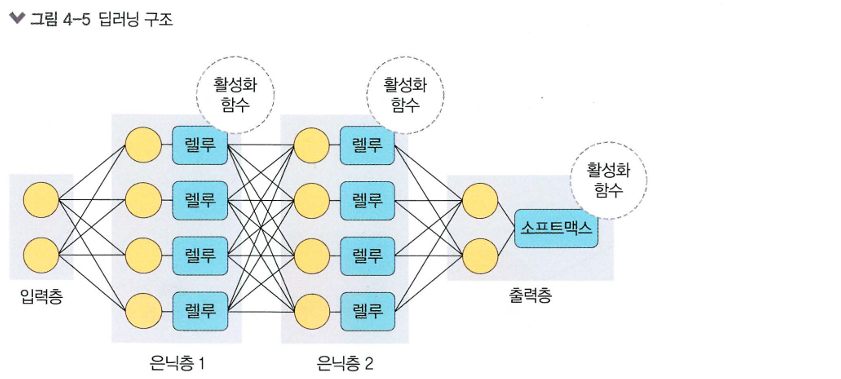

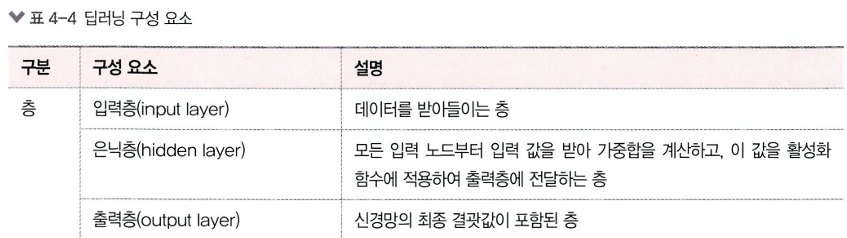

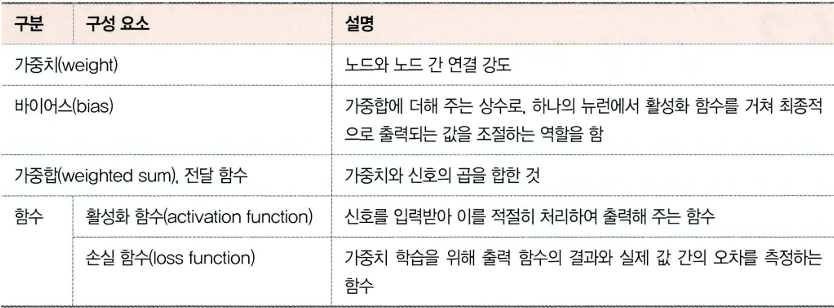

**활성화 함수**

1. 시그모이드 함수
2. 하이퍼볼릭 탄젠트 함수
3. 렐루 함수
4. 리키 렐루 함수
5. 소프트맥스 함수

In [1]:
import torch

In [2]:
# ReLU와 Softmax 구현

class Net(torch.nn.Module):
    def __init__(self, n_feature, n_hidden, n_output):
        super(Net, self).__init__()
        self.hidden = torch.nn.Linear(n_feature, n_hidden)  # 은닉층
        self.relu = torch.nn.ReLU(inplace=True)
        self.out = torch.nn.Linear(n_hidden, n_output)  # 출력층
        self.softmax = torch.nn.Softmax(dim=n_output)
    def forward(self,x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.out(x)
        x = self.softmax(x)
        return x

**손실 함수**
1. 평균 제곱 오차 - 회귀에서 손실함수로 주로 사용됨

In [ ]:
import torch
loss_fn = torch.nn.MSELoss(reduction='sum')
y_pred = model(x)
loss = loss_fn(y_pred, y)

2. 크로스 엔트로피 오차 - 주로 분류 문제에서 원-핫 인코딩 했을 때 사용할 수 있는 오차 계산법

In [ ]:
loss = nn.CrossEntropyLoss()
input = torch.randn(5,6,requires_grad=True)
target = torch.empty(3,dtype=torch.long).random_(5)
output = loss(input, target)
output.backward()

### **2.2. 딥러닝 학습**

딥러닝 학습은 크게 순전파와 역전파라는 두 단계로 진행된다.

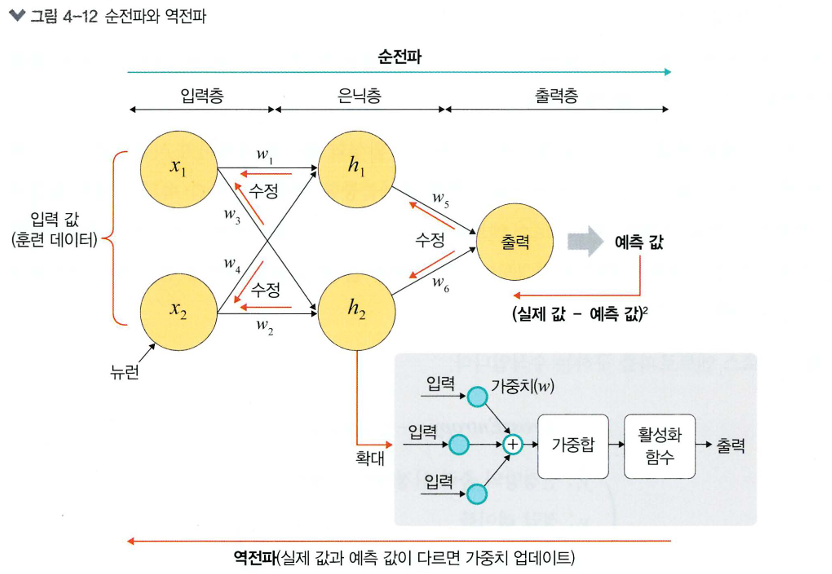

첫 번째 단계인 **순전파(feedforward)** 는 네트워크에 훈련 데이터가 들어올 때 발생하며, 데이터를 기반으로 예측 값을 계산하기 위해 전체 신경망을 교차해 지나간다.

그 다음 손실 함수로 네트워크의 예측 값과 실제 값의 차이를 추정한다. 이때 손실 함수 비용은 '0'이 가장 이상적이다. 따라서, 손실 함수 비용이 0에 가깝도록 하기 위해 모델이 훈련을 반복하면서 가중치를 조정한다. 손실이 계산되면 그 정보는 역으로 전파되기 때문에 **역전파(backpropagation)** 라고 한다. 출력층에서 시작된 손실 비용은 은닉층의 모든 뉴런으로 전파되지만, 은닉층의 뉴런은 각 뉴런이 원래 출력에 기여한 상대적 기여도에 따라 값이 달라진다.
이 과정을 출력층 -> 은닉층 -> 입력층 순서로 모든 뉴런에 대해 진행하여 계산된 뉴런 결과를 또다시 순전파의 가중치 값으로 사용한다.

### **2.3. 딥러닝의 문제점과 해결 방안**

딥러닝의 핵심은 활성화 함수가 적용된 여러 은닉층을 결합하여 비선형 영역을 표현하는 것이다. 하지만, 은닉층이 많을수록 다음 세 가지 문제점이 생긴다.

#### **과적합 문제 발생**
과적합은 훈련 데이터에 과하게 학습하여 실제 데이터에 대한 오차가 증가하는 현상을 의미한다. 과적합을 해결하는 방법으로 **드롭아웃(dropout)** 이 있다.

신경망 모델이 과적합되는 것을 피하기 위한 방법으로 학습 과정 중 임의로 일부 노드드을 학습에서 제외시킨다.

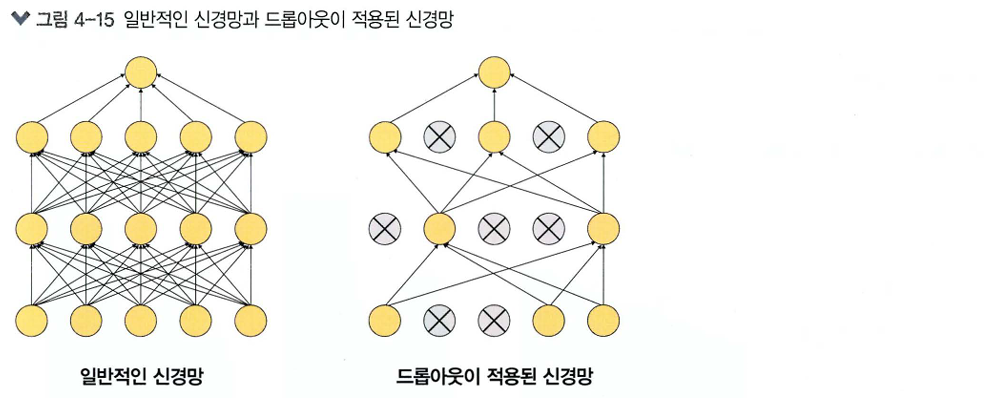

In [3]:
class DropoutModel(torch.nn.Module):
    def __init__(self):
        super(DropoutModel, self).__init__()
        self.layer1 = torch.nn.Linear(784,1200)
        self.dropout1 = torch.nn.Dropout(0.5)
        self.layer2 = torch.nn.Linear(1200,1200)
        self.dropout2 = torch.nn.Dropout(0.5)
        self.layer3 = torch.nn.Linear(1200,10)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = self.dropout1(x)
        x = F.relu(self.layer2(x))
        x = self.dropout2(x)
        return self.layer3(x)

#### **기울기 소멸 문제 발생**
기울기 소멸 문제는 학습되는 양이 0에 가까워져 학습이 더디게 진행되다가 오차를 더 줄이지 못하고 그 상태로 수렴하는 현상이다.

기울기 소멸 문제는 시그모이드나 하이퍼볼릭 탄젠트 대신 **렐루** 활성화 함수를 사용하면 해결할 수 있다.

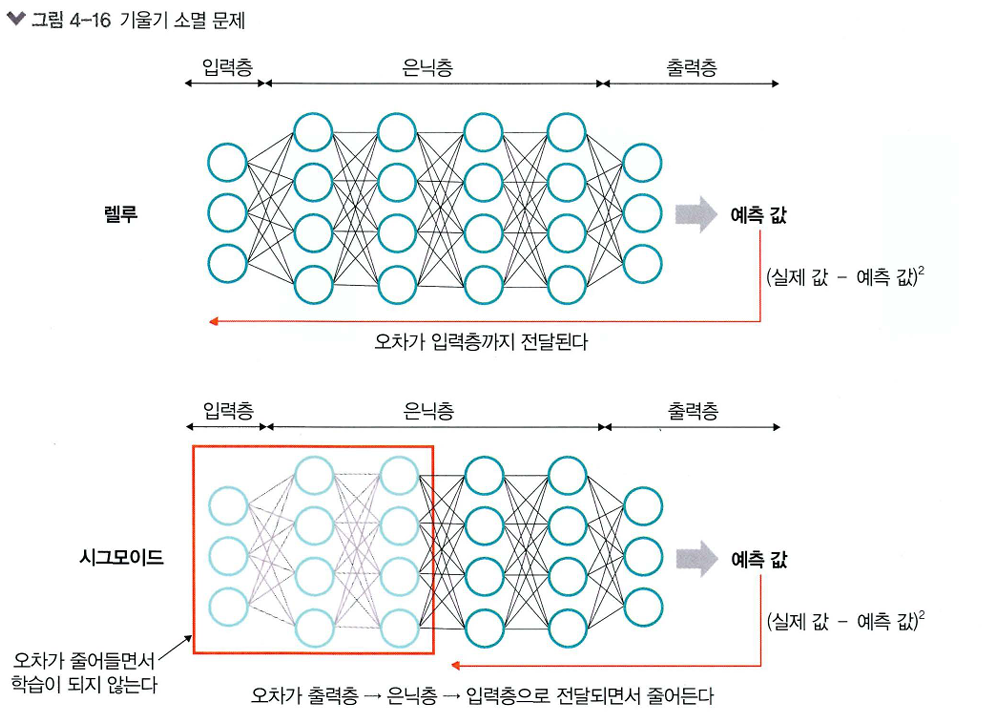

#### **성능이 나빠지는 문제 발생**
경사 하강법은 손실 함수의 비용이 최소가 되는 지점을 찾을 때까지 기울기가 낮은 쪽으로 계속 이동시키는 과정을 반복하는데, 이때 성능이 나빠지는 문제가 발생한다.

이러한 문제점을 개선하고자 **확률적 경사 하강법**과 **미니 배치 경사 하강법**을 사용한다.

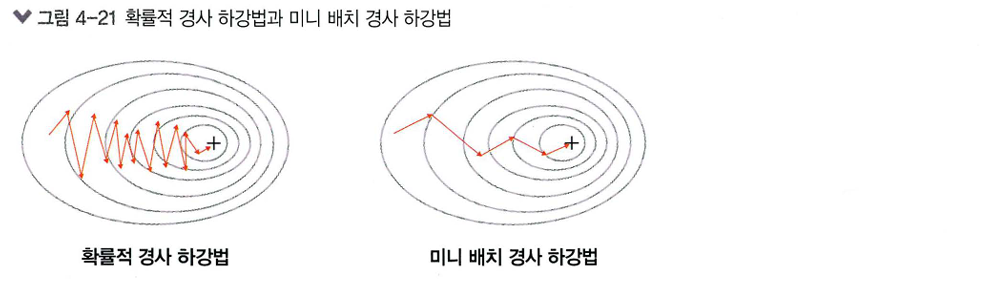

In [ ]:
class CustomDataset(Dataset):
    def __init__(self):
        self.x_data = [[1,2,3],[4,5,6],[7,8,9]]
        self.y_data = [[12],[18],[11]]
        def __len__(self):
            return len(self.x_data)
        def __getitem__(self,idx):
            x = torch.FloatTensor(self.x_data[idx])
            y = torch.FloatTensor(self.y_data[idx])
            return x, y

dataset = CustomDataset()
data = DataLoader(
    dataset,
    batch_size=2,
    shuffle = True
)

### **2.4. 딥러닝을 사용할 때 이점**

#### **특성 추출**
데이터를 분석하기 위해 데이터별로 어떤 특징을 가지고 있는지 찾아내고, 그것을 토대로 데이터를 벡터로 변환하는 작업을 특성 추출이라고 한다.

딥러닝이 활성화되기 이전에 많이 사용되었던 머신러닝 알고리즘인 SVM, 나이브베이즈, 로지스틱 회귀의 특성 추출은 매우 복잡하며 수집된 데이터에 대한 전문 지식이 필요하다. 하지만, 딥러닝에서는 특성 추출 과정을 알고리즘에 통합시켰다.

#### **빅데이터의 효율적 활용**
딥러닝을 사용할 때, 특성 추출이 가능한 이유는 빅데이터 때문이다. 딥러닝 학습을 이용한 특성 추출은 데이터 사례가 많을수록 성능이 향상되기 때문이다.

## **3. 딥러닝 알고리즘**

### **3.1. 심층 신경망**

**심층 신경망(DNN)** 은 입력층과 출력층 사이에 다수의 은닉층을 포함하는 인공 신경망이다.

다수의 은닉층을 두었기 때문에 다양한 비선형적 관계를 학습할 수 있는 장점이 있지만, 학습을 위한 연산량이 많고 기울기 소멸 문제 등이 발생할 수 있다. 이러한 문제를 해결하기 위해 드롭아웃, 렐루 함수, 배치 정규화 등을 적용해야 한다.

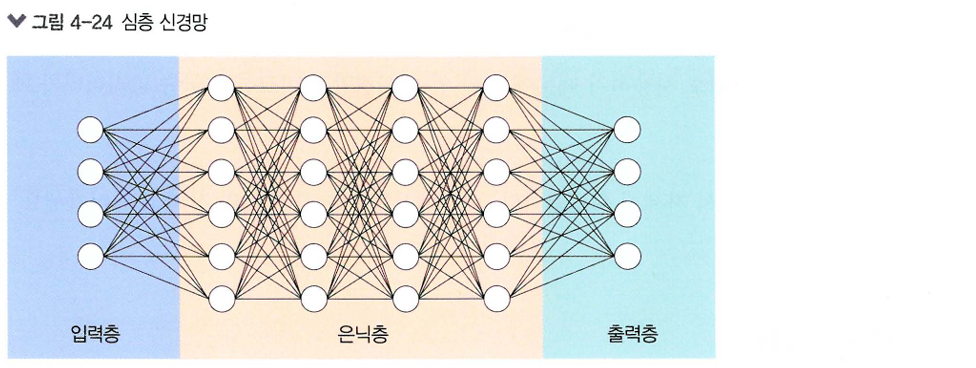

### **3.2. 합성곱 신경망**

**합성곱 신경망(CNN)** 은 합성곱층과 풀링층을 포함하는 **이미지 처리 성능**이 좋은 인공 신경망 알고리즘이다. 영상 및 사진이 포함된 이미지 데이터에서 객체를 탐색하거나 객체 위치를 찾아내는 데 유용한 신경망이다.

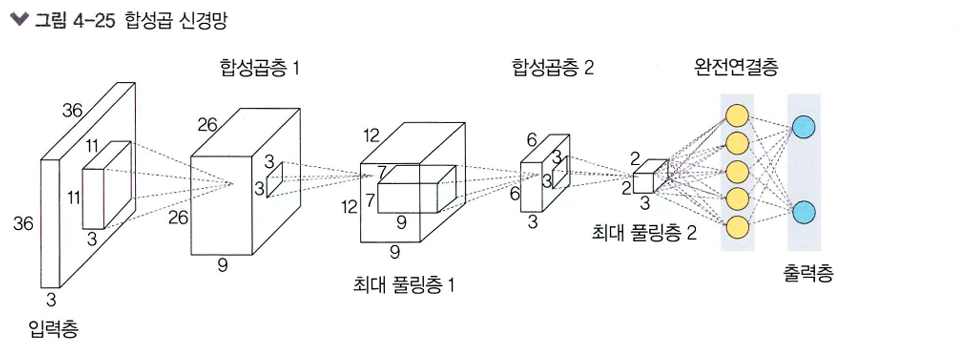

대표적인 합성곱 신경망으로 LeNet-5, AlexNet이 있으며, 층을 더 깊게 쌓은 신경망으로 VGG, GoogleNet, ResNet 등이 있다.

### **3.3. 순환 신경망**

**순환 신경망(RNN)** 은 **시계열 데이터** 같은 시간 흐름에 따라 변화하는 데이터를 학습하기 위한 인공 신경망이다. 따라서, 현재 결과가 이전 결과와 연관이 있다는 것을 의미한다.

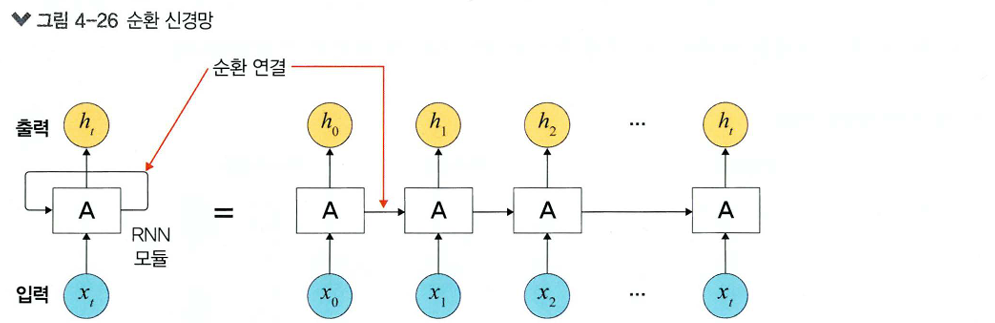

순환 신경망은 기울기 소멸 문제로 학습이 제대로 되지 않는 문제가 있다. 이를 해겨랗고자 메모리 개념을 도입한 LSTM이 순환 신경망에서 많이 사용되고 있다.


### **3.3. 제한된 볼츠만 머신**
**볼츠만 머신(Boltzmann machine)** 은 가시층과 은닉층으로 구성된 모델이다. 이 모델에서 가시층은 은닉층과만 연결되는데 이것이 제한된 볼츠만 머신이다.

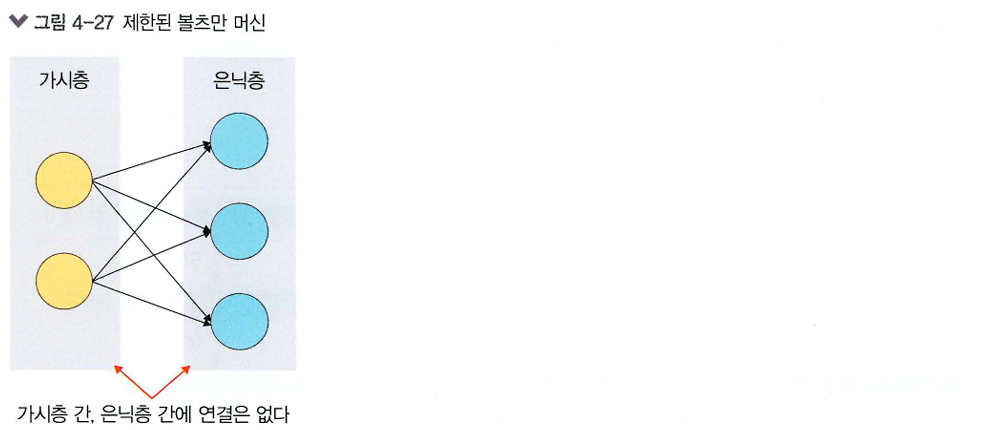

### **3.5. 심층 신뢰 신경망**
**심층 신뢰 신경망(DBN)** 은 입력층과 은닉층으로 구성된 제한된 볼츠만 머신을 블록처럼 여러 층으로 쌓은 형태로 연결된 신경망이다. 즉, 사전 훈련된 제한된 볼츠만 머신을 층층이 쌓아 올린 구조로, 레이블이 없는 데이터에 대한 비지도 학습이 가능하다.

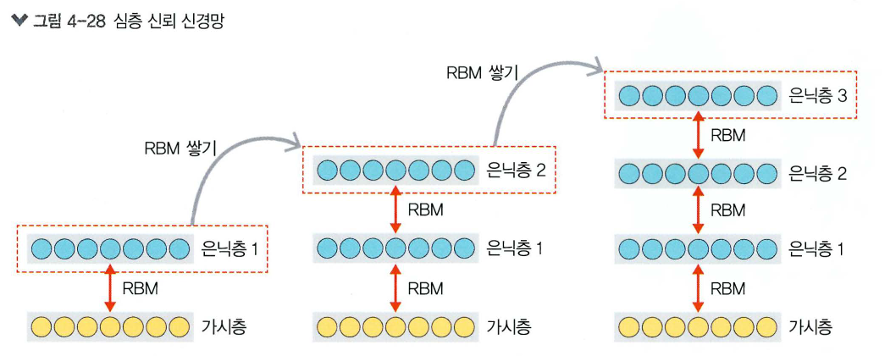